SBP: 收缩压 | Systolic Blood Pressure | mmHg
MAP: 平均动脉压 | Mean Arterial Pressure | mmHg
sPAP: 肺动脉收缩压 | Systolic Pulmonary Arterial Pressure | mmHg
dPAP: 肺动脉舒张压 | Diastolic Pulmonary Arterial Pressure | mmHg

SBP range: 44.01 to 158.86
MAP range: 28.62 to 145.17
Quick match counts with current tolerance:
  SBP=10, MAP=90 -> 0 cases
  SBP=100, MAP=90 -> 25 cases
  SBP=110, MAP=90 -> 110 cases
  SBP=120, MAP=90 -> 18 cases

筛选条件: SBP in [99.0, 101.0], MAP in [89.0, 91.0]
匹配 case 数量: 25
前 5 个匹配 case:
{'case_id': 'case_02386', 'SBP': 100.781301, 'MAP': 90.73596556, 'sPAP': 28.10161203, 'dPAP': 14.53733287}
{'case_id': 'case_03771', 'SBP': 99.79275866, 'MAP': 90.36791262, 'sPAP': 27.62644201, 'dPAP': 14.04581045}
{'case_id': 'case_04162', 'SBP': 99.39692081, 'MAP': 89.30026053, 'sPAP': 23.57280784, 'dPAP': 14.65875101}
{'case_id': 'case_05338', 'SBP': 99.65302426, 'MAP': 89.20675986, 'sPAP': 31.53286366, 'dPAP': 16.86166719}
{'case_id': 'case_06752', 'SBP': 100.9187906, 'MAP': 90.05559719, 'sPA

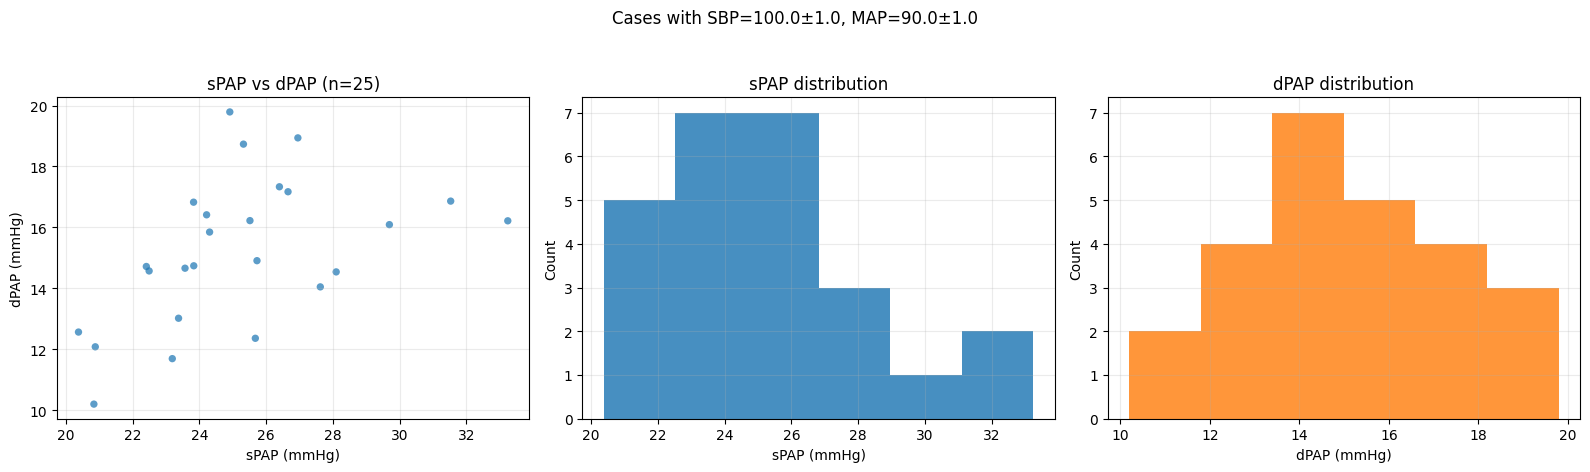

In [2]:
from pathlib import Path
import csv
import math
import statistics as stats

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt

DATA_PATH = Path("dataset_40k_cases.csv")
SUMMARY_INFO_PATH = Path("hemodynamic_summary.csv")

# 筛选条件：按需要直接改这里
TARGET_SBP = 100.0
TARGET_MAP = 90.0
TOLERANCE = 1.0

required_columns = ["case_id", "SBP", "MAP", "sPAP", "dPAP"]


# 读取指标说明
with SUMMARY_INFO_PATH.open(newline="", encoding="utf-8-sig") as f:
    summary_rows = list(csv.DictReader(f))

for name in ["SBP", "MAP", "sPAP", "dPAP"]:
    row = next((r for r in summary_rows if r.get("指标名") == name), None)
    if row:
        print(f"{name}: {row.get('中文名', '')} | {row.get('英文名', '')} | {row.get('单位', '')}")


# 快速检查 SBP/MAP 范围，确认目标值是否合理
sbp_values = []
map_values = []
quick_targets = [(10, 90), (100, 90), (110, 90), (120, 90)]
quick_counts = {target: 0 for target in quick_targets}

with DATA_PATH.open(newline="", encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)
    for row in reader:
        sbp = float(row["SBP"])
        map_ = float(row["MAP"])
        sbp_values.append(sbp)
        map_values.append(map_)

        for target_sbp, target_map in quick_targets:
            if abs(sbp - target_sbp) <= TOLERANCE and abs(map_ - target_map) <= TOLERANCE:
                quick_counts[(target_sbp, target_map)] += 1

print(f"\nSBP range: {min(sbp_values):.2f} to {max(sbp_values):.2f}")
print(f"MAP range: {min(map_values):.2f} to {max(map_values):.2f}")
print("Quick match counts with current tolerance:")
for target, count in quick_counts.items():
    print(f"  SBP={target[0]}, MAP={target[1]} -> {count} cases")


# 按 SBP/MAP 条件筛选 case
def to_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return math.nan


matched = []

with DATA_PATH.open(newline="", encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)
    missing = [col for col in required_columns if col not in reader.fieldnames]
    if missing:
        raise ValueError(f"CSV 缺少这些列: {missing}")

    for row in reader:
        sbp = to_float(row["SBP"])
        map_ = to_float(row["MAP"])

        if abs(sbp - TARGET_SBP) <= TOLERANCE and abs(map_ - TARGET_MAP) <= TOLERANCE:
            matched.append({
                "case_id": row["case_id"],
                "SBP": sbp,
                "MAP": map_,
                "sPAP": to_float(row["sPAP"]),
                "dPAP": to_float(row["dPAP"]),
            })

print(
    f"\n筛选条件: SBP in [{TARGET_SBP - TOLERANCE}, {TARGET_SBP + TOLERANCE}], "
    f"MAP in [{TARGET_MAP - TOLERANCE}, {TARGET_MAP + TOLERANCE}]"
)
print(f"匹配 case 数量: {len(matched)}")
print("前 5 个匹配 case:")
for row in matched[:5]:
    print(row)


# sPAP / dPAP 简单统计
def describe(values):
    clean = [v for v in values if not math.isnan(v)]
    if not clean:
        return {"n": 0}

    return {
        "n": len(clean),
        "min": min(clean),
        "mean": stats.fmean(clean),
        "median": stats.median(clean),
        "max": max(clean),
    }


sPAP_values = [row["sPAP"] for row in matched]
dPAP_values = [row["dPAP"] for row in matched]

print("\nsPAP:", describe(sPAP_values))
print("dPAP:", describe(dPAP_values))


# 绘图观察分布
valid_points = [
    row for row in matched
    if not math.isnan(row["sPAP"]) and not math.isnan(row["dPAP"])
]

if not valid_points:
    print("\n没有找到可绘制的匹配点。可以尝试增大 TOLERANCE，或检查 TARGET_SBP / TARGET_MAP 是否写对。")
else:
    x = [row["sPAP"] for row in valid_points]
    y = [row["dPAP"] for row in valid_points]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    axes[0].scatter(x, y, s=28, alpha=0.72, edgecolors="none")
    axes[0].set_title(f"sPAP vs dPAP (n={len(valid_points)})")
    axes[0].set_xlabel("sPAP (mmHg)")
    axes[0].set_ylabel("dPAP (mmHg)")
    axes[0].grid(True, alpha=0.25)

    axes[1].hist(x, bins="auto", alpha=0.82)
    axes[1].set_title("sPAP distribution")
    axes[1].set_xlabel("sPAP (mmHg)")
    axes[1].set_ylabel("Count")
    axes[1].grid(True, alpha=0.25)

    axes[2].hist(y, bins="auto", alpha=0.82, color="tab:orange")
    axes[2].set_title("dPAP distribution")
    axes[2].set_xlabel("dPAP (mmHg)")
    axes[2].set_ylabel("Count")
    axes[2].grid(True, alpha=0.25)

    fig.suptitle(
        f"Cases with SBP={TARGET_SBP}±{TOLERANCE}, MAP={TARGET_MAP}±{TOLERANCE}",
        y=1.04,
    )
    plt.tight_layout()
    plt.show()


In [3]:
from scipy.stats import gaussian_kde
import numpy as np

points = np.array([[row["sPAP"], row["dPAP"]] for row in valid_points]).T

kde = gaussian_kde(points)

s_grid = np.linspace(min(sPAP_values), max(sPAP_values), 200)
d_grid = np.linspace(min(dPAP_values), max(dPAP_values), 200)
S, D = np.meshgrid(s_grid, d_grid)

grid_points = np.vstack([S.ravel(), D.ravel()])
density = kde(grid_points)

max_idx = density.argmax()
mle_sPAP = grid_points[0, max_idx]
mle_dPAP = grid_points[1, max_idx]

best_case = min(
    valid_points,
    key=lambda row: (row["sPAP"] - mle_sPAP) ** 2 + (row["dPAP"] - mle_dPAP) ** 2
)

mle_sPAP, mle_dPAP, best_case


(np.float64(24.259277220301506),
 np.float64(15.595371148693467),
 {'case_id': 'case_13793',
  'SBP': 100.3469664,
  'MAP': 89.56183737,
  'sPAP': 24.30910421,
  'dPAP': 15.84535784})

Loaded rows: 40000
Random target found:
  TARGET_SBP = 136.562
  TARGET_MAP = 109.991
  hard match count within ±1.0: 5

Hard matched cases:
case_00625 SBP=135.97 MAP=110.24 sPAP=22.20 dPAP=12.13
case_02317 SBP=135.91 MAP=109.41 sPAP=22.28 dPAP=13.37
case_16795 SBP=135.91 MAP=109.22 sPAP=24.44 dPAP=14.59
case_27301 SBP=136.74 MAP=109.45 sPAP=27.82 dPAP=18.10
case_30482 SBP=137.41 MAP=110.62 sPAP=21.08 dPAP=13.10

Weighted KNN continuous prediction:
  predicted sPAP = 23.836
  predicted dPAP = 13.800

Nearest real case to weighted prediction:
  case_id = case_11363
  SBP = 137.738
  MAP = 115.562
  sPAP = 23.711
  dPAP = 13.708
  normalized SBP/MAP distance = 0.3310
  weight = 0.9759


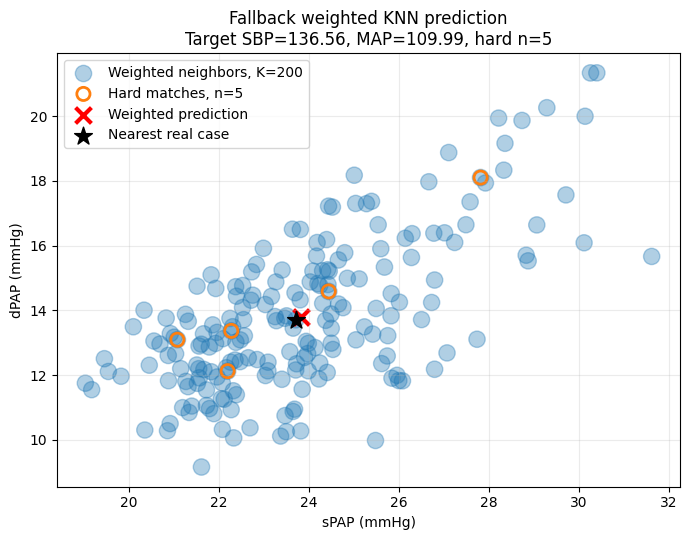

In [4]:
from pathlib import Path
import csv
import math
import random
import statistics as stats

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt


DATA_PATH = Path("dataset_40k_cases.csv")

TOLERANCE = 1.0
RANDOM_SEED = 42

# 近邻参数
K_NEIGHBORS = 200
BANDWIDTH = 1.5
MAX_RANDOM_TRIES = 5000

random.seed(RANDOM_SEED)


def to_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return math.nan


# 读取需要的列
rows = []

with DATA_PATH.open(newline="", encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)

    required = ["case_id", "SBP", "MAP", "sPAP", "dPAP"]
    missing = [col for col in required if col not in reader.fieldnames]
    if missing:
        raise ValueError(f"CSV 缺少这些列: {missing}")

    for row in reader:
        parsed = {
            "case_id": row["case_id"],
            "SBP": to_float(row["SBP"]),
            "MAP": to_float(row["MAP"]),
            "sPAP": to_float(row["sPAP"]),
            "dPAP": to_float(row["dPAP"]),
        }

        if all(not math.isnan(parsed[col]) for col in ["SBP", "MAP", "sPAP", "dPAP"]):
            rows.append(parsed)

print(f"Loaded rows: {len(rows)}")


# 先随机找一个 hard match 数量 < 10 的 SBP/MAP 组合
sbp_min, sbp_max = min(r["SBP"] for r in rows), max(r["SBP"] for r in rows)
map_min, map_max = min(r["MAP"] for r in rows), max(r["MAP"] for r in rows)

candidate = None

for _ in range(MAX_RANDOM_TRIES):
    target_sbp = random.uniform(sbp_min, sbp_max)
    target_map = random.uniform(map_min, map_max)

    hard_matches = [
        r for r in rows
        if abs(r["SBP"] - target_sbp) <= TOLERANCE
        and abs(r["MAP"] - target_map) <= TOLERANCE
    ]

    if 0 < len(hard_matches) < 10:
        candidate = {
            "TARGET_SBP": target_sbp,
            "TARGET_MAP": target_map,
            "hard_matches": hard_matches,
        }
        break

if candidate is None:
    raise RuntimeError("没有随机找到 0 < 匹配数 < 10 的组合，可以增加 MAX_RANDOM_TRIES。")

TARGET_SBP = candidate["TARGET_SBP"]
TARGET_MAP = candidate["TARGET_MAP"]
hard_matches = candidate["hard_matches"]

print(f"Random target found:")
print(f"  TARGET_SBP = {TARGET_SBP:.3f}")
print(f"  TARGET_MAP = {TARGET_MAP:.3f}")
print(f"  hard match count within ±{TOLERANCE}: {len(hard_matches)}")

print("\nHard matched cases:")
for r in hard_matches:
    print(
        r["case_id"],
        f"SBP={r['SBP']:.2f}",
        f"MAP={r['MAP']:.2f}",
        f"sPAP={r['sPAP']:.2f}",
        f"dPAP={r['dPAP']:.2f}",
    )


# SBP/MAP 距离加权近邻预测
#
# 这里先用全数据的标准差做尺度归一化：
# distance = sqrt(((SBP-target_SBP)/std_SBP)^2 + ((MAP-target_MAP)/std_MAP)^2)
#
# 然后取距离最近的 K 个点，用 Gaussian kernel 加权：
# weight = exp(-0.5 * (distance / BANDWIDTH)^2)

std_sbp = stats.stdev([r["SBP"] for r in rows])
std_map = stats.stdev([r["MAP"] for r in rows])

neighbors = []

for r in rows:
    dist = math.sqrt(
        ((r["SBP"] - TARGET_SBP) / std_sbp) ** 2
        + ((r["MAP"] - TARGET_MAP) / std_map) ** 2
    )

    neighbors.append({
        **r,
        "distance": dist,
    })

neighbors = sorted(neighbors, key=lambda r: r["distance"])[:K_NEIGHBORS]

for r in neighbors:
    r["weight"] = math.exp(-0.5 * (r["distance"] / BANDWIDTH) ** 2)

weight_sum = sum(r["weight"] for r in neighbors)

pred_sPAP = sum(r["weight"] * r["sPAP"] for r in neighbors) / weight_sum
pred_dPAP = sum(r["weight"] * r["dPAP"] for r in neighbors) / weight_sum

print("\nWeighted KNN continuous prediction:")
print(f"  predicted sPAP = {pred_sPAP:.3f}")
print(f"  predicted dPAP = {pred_dPAP:.3f}")


# 为了避免预测出不存在的 case：
# 找一个真实 case，它的 sPAP/dPAP 最接近加权预测结果。
# 这里限定在 K 个近邻里找，这样它不仅 hemodynamic 接近，也在 SBP/MAP 条件附近。

nearest_real_case = min(
    neighbors,
    key=lambda r: (r["sPAP"] - pred_sPAP) ** 2 + (r["dPAP"] - pred_dPAP) ** 2
)

print("\nNearest real case to weighted prediction:")
print(f"  case_id = {nearest_real_case['case_id']}")
print(f"  SBP = {nearest_real_case['SBP']:.3f}")
print(f"  MAP = {nearest_real_case['MAP']:.3f}")
print(f"  sPAP = {nearest_real_case['sPAP']:.3f}")
print(f"  dPAP = {nearest_real_case['dPAP']:.3f}")
print(f"  normalized SBP/MAP distance = {nearest_real_case['distance']:.4f}")
print(f"  weight = {nearest_real_case['weight']:.4f}")


# 可视化：近邻样本 + hard matches + 加权预测点 + 最近真实 case
x = [r["sPAP"] for r in neighbors]
y = [r["dPAP"] for r in neighbors]
weights = [r["weight"] for r in neighbors]

# 点大小随权重变化
max_w = max(weights)
sizes = [20 + 120 * (w / max_w) for w in weights]

plt.figure(figsize=(7, 5.5))

plt.scatter(
    x,
    y,
    s=sizes,
    alpha=0.35,
    label=f"Weighted neighbors, K={K_NEIGHBORS}",
)

if hard_matches:
    plt.scatter(
        [r["sPAP"] for r in hard_matches],
        [r["dPAP"] for r in hard_matches],
        s=90,
        facecolors="none",
        edgecolors="tab:orange",
        linewidths=2,
        label=f"Hard matches, n={len(hard_matches)}",
    )

plt.scatter(
    [pred_sPAP],
    [pred_dPAP],
    marker="x",
    s=130,
    color="red",
    linewidths=3,
    label="Weighted prediction",
)

plt.scatter(
    [nearest_real_case["sPAP"]],
    [nearest_real_case["dPAP"]],
    marker="*",
    s=180,
    color="black",
    label="Nearest real case",
)

plt.title(
    f"Fallback weighted KNN prediction\n"
    f"Target SBP={TARGET_SBP:.2f}, MAP={TARGET_MAP:.2f}, hard n={len(hard_matches)}"
)
plt.xlabel("sPAP (mmHg)")
plt.ylabel("dPAP (mmHg)")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


Loaded rows: 40000


Running case1
Target: SBP=100.00, MAP=90.00
Mode: hard_match_density
Hard match count within ±1.0: 25
Candidate count used for ranking: 25
Top-3 confidence mass: 0.188

Top 1
  case_id: case_13793
  confidence_score: 0.064
  SBP=100.347, MAP=89.562
  sPAP=24.309, dPAP=15.845
  normalized input distance: 0.0323
  outcome density score: 7.2852

Top 2
  case_id: case_06752
  confidence_score: 0.062
  SBP=100.919, MAP=90.056
  sPAP=23.835, dPAP=14.738
  normalized input distance: 0.0527
  outcome density score: 7.0569

Top 3
  case_id: case_04162
  confidence_score: 0.061
  SBP=99.397, MAP=89.300
  sPAP=23.573, dPAP=14.659
  normalized input distance: 0.0534
  outcome density score: 6.9165



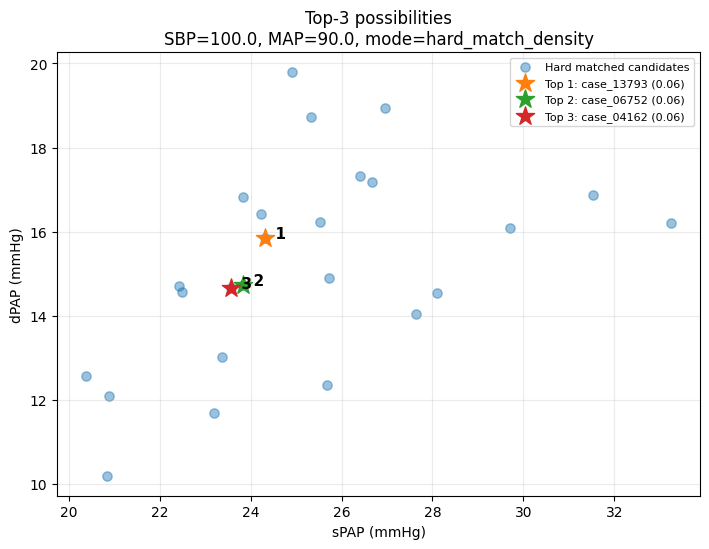



Running case2
Target: SBP=136.00, MAP=110.00
Mode: fallback_weighted_input_neighbors
Hard match count within ±1.0: 4
Candidate count used for ranking: 300
Top-3 confidence mass: 0.027

Top 1
  case_id: case_06342
  confidence_score: 0.009
  SBP=134.074, MAP=110.139
  sPAP=22.380, dPAP=13.018
  normalized input distance: 0.1105
  outcome density score: 42.8831

Top 2
  case_id: case_02317
  confidence_score: 0.009
  SBP=135.909, MAP=109.410
  sPAP=22.277, dPAP=13.369
  normalized input distance: 0.0347
  outcome density score: 40.9131

Top 3
  case_id: case_00625
  confidence_score: 0.009
  SBP=135.967, MAP=110.244
  sPAP=22.195, dPAP=12.126
  normalized input distance: 0.0143
  outcome density score: 40.0416



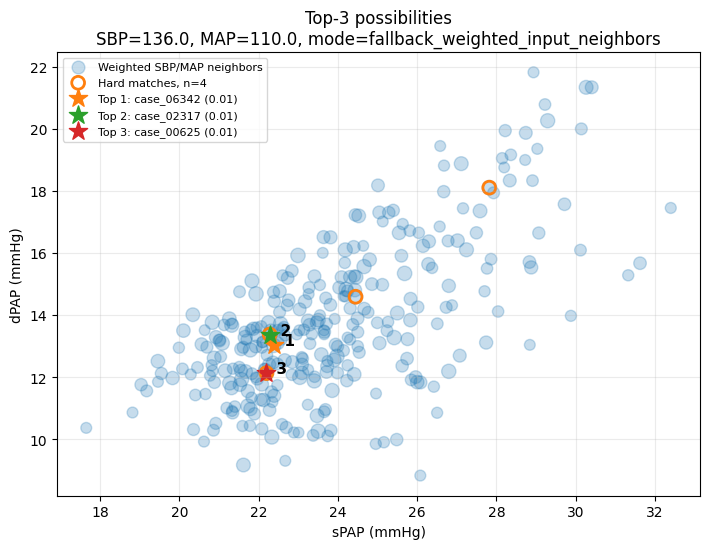

In [5]:
from pathlib import Path
import csv
import math
import statistics as stats

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt


DATA_PATH = Path("dataset_40k_cases.csv")

TOLERANCE = 1.0
MIN_HARD_MATCHES = 10
TOP_K = 3

# fallback 近邻参数
K_INPUT_NEIGHBORS = 300
INPUT_BANDWIDTH = 0.35

# outcome KDE bandwidth 下限，避免样本太少时 bandwidth 过小
MIN_SPAP_BW = 0.8
MIN_DPAP_BW = 0.8


def to_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return math.nan


def gaussian_kernel_2d(dx, dy, bw_x, bw_y):
    z = (dx / bw_x) ** 2 + (dy / bw_y) ** 2
    return math.exp(-0.5 * z)


def safe_stdev(values, fallback=1.0):
    if len(values) < 2:
        return fallback
    s = stats.stdev(values)
    return s if s > 0 else fallback


def choose_bandwidth(values, min_bw):
    """
    简化版 Silverman 思路：
    bandwidth ~ std * n^(-1/6)，适用于二维 KDE 的温和估计。
    同时设置下限，避免小样本过拟合。
    """
    n = len(values)
    if n < 2:
        return min_bw

    sd = safe_stdev(values, fallback=min_bw)
    bw = sd * (n ** (-1 / 6))
    return max(bw, min_bw)


def load_rows(path):
    rows = []

    with path.open(newline="", encoding="utf-8-sig") as f:
        reader = csv.DictReader(f)

        required = ["case_id", "SBP", "MAP", "sPAP", "dPAP"]
        missing = [col for col in required if col not in reader.fieldnames]
        if missing:
            raise ValueError(f"CSV 缺少这些列: {missing}")

        for row in reader:
            parsed = {
                "case_id": row["case_id"],
                "SBP": to_float(row["SBP"]),
                "MAP": to_float(row["MAP"]),
                "sPAP": to_float(row["sPAP"]),
                "dPAP": to_float(row["dPAP"]),
            }

            if all(not math.isnan(parsed[col]) for col in ["SBP", "MAP", "sPAP", "dPAP"]):
                rows.append(parsed)

    return rows


def hard_match(rows, target_sbp, target_map, tolerance):
    return [
        r for r in rows
        if abs(r["SBP"] - target_sbp) <= tolerance
        and abs(r["MAP"] - target_map) <= tolerance
    ]


def add_input_distance_and_weight(rows, target_sbp, target_map, std_sbp, std_map):
    weighted = []

    for r in rows:
        input_distance = math.sqrt(
            ((r["SBP"] - target_sbp) / std_sbp) ** 2
            + ((r["MAP"] - target_map) / std_map) ** 2
        )

        input_weight = math.exp(-0.5 * (input_distance / INPUT_BANDWIDTH) ** 2)

        weighted.append({
            **r,
            "input_distance": input_distance,
            "input_weight": input_weight,
        })

    return weighted


def rank_possibilities(candidates, use_input_weight=True):
    """
    对候选真实 case 排序。

    score_i = input_weight_i * sum_j input_weight_j * KDE_outcome(y_i, y_j)

    直觉：
    1. input_weight_i: 这个 case 的 SBP/MAP 是否接近目标输入；
    2. KDE_outcome: 这个 case 的 sPAP/dPAP 是否位于候选结果的高密度区域；
    3. 最终 confidence_score 是所有候选 score 归一化后的相对分数。
    """
    if not candidates:
        return []

    spap_values = [r["sPAP"] for r in candidates]
    dpap_values = [r["dPAP"] for r in candidates]

    bw_spap = choose_bandwidth(spap_values, MIN_SPAP_BW)
    bw_dpap = choose_bandwidth(dpap_values, MIN_DPAP_BW)

    scored = []

    for i, r in enumerate(candidates):
        input_weight_i = r.get("input_weight", 1.0) if use_input_weight else 1.0
        outcome_density = 0.0

        for j, other in enumerate(candidates):
            input_weight_j = other.get("input_weight", 1.0) if use_input_weight else 1.0

            outcome_density += input_weight_j * gaussian_kernel_2d(
                r["sPAP"] - other["sPAP"],
                r["dPAP"] - other["dPAP"],
                bw_spap,
                bw_dpap,
            )

        raw_score = input_weight_i * outcome_density

        scored.append({
            **r,
            "raw_score": raw_score,
            "outcome_density": outcome_density,
        })

    total_score = sum(r["raw_score"] for r in scored)

    for r in scored:
        r["confidence_score"] = r["raw_score"] / total_score if total_score > 0 else 0.0

    return sorted(scored, key=lambda r: r["confidence_score"], reverse=True)


def predict_top_k_possibilities(rows, target_sbp, target_map, top_k=3):
    hard_matches = hard_match(rows, target_sbp, target_map, TOLERANCE)

    sbp_values = [r["SBP"] for r in rows]
    map_values = [r["MAP"] for r in rows]
    std_sbp = safe_stdev(sbp_values)
    std_map = safe_stdev(map_values)

    if len(hard_matches) >= MIN_HARD_MATCHES:
        mode = "hard_match_density"
        candidates = [
            {
                **r,
                "input_distance": math.sqrt(
                    ((r["SBP"] - target_sbp) / std_sbp) ** 2
                    + ((r["MAP"] - target_map) / std_map) ** 2
                ),
                "input_weight": 1.0,
            }
            for r in hard_matches
        ]

        ranked = rank_possibilities(candidates, use_input_weight=False)

    else:
        mode = "fallback_weighted_input_neighbors"

        weighted_rows = add_input_distance_and_weight(
            rows,
            target_sbp,
            target_map,
            std_sbp,
            std_map,
        )

        candidates = sorted(weighted_rows, key=lambda r: r["input_distance"])[:K_INPUT_NEIGHBORS]
        ranked = rank_possibilities(candidates, use_input_weight=True)

    top = ranked[:top_k]
    top_confidence_mass = sum(r["confidence_score"] for r in top)

    return {
        "target_sbp": target_sbp,
        "target_map": target_map,
        "mode": mode,
        "hard_match_count": len(hard_matches),
        "candidate_count": len(candidates),
        "top_confidence_mass": top_confidence_mass,
        "top_cases": top,
        "all_ranked": ranked,
        "hard_matches": hard_matches,
    }


def print_prediction(result):
    print("=" * 80)
    print(f"Target: SBP={result['target_sbp']:.2f}, MAP={result['target_map']:.2f}")
    print(f"Mode: {result['mode']}")
    print(f"Hard match count within ±{TOLERANCE}: {result['hard_match_count']}")
    print(f"Candidate count used for ranking: {result['candidate_count']}")
    print(f"Top-{TOP_K} confidence mass: {result['top_confidence_mass']:.3f}")
    print()

    for idx, r in enumerate(result["top_cases"], start=1):
        print(f"Top {idx}")
        print(f"  case_id: {r['case_id']}")
        print(f"  confidence_score: {r['confidence_score']:.3f}")
        print(f"  SBP={r['SBP']:.3f}, MAP={r['MAP']:.3f}")
        print(f"  sPAP={r['sPAP']:.3f}, dPAP={r['dPAP']:.3f}")
        print(f"  normalized input distance: {r.get('input_distance', 0.0):.4f}")
        print(f"  outcome density score: {r['outcome_density']:.4f}")
        print()


def plot_prediction(result):
    ranked = result["all_ranked"]
    top_cases = result["top_cases"]
    hard_matches = result["hard_matches"]

    plt.figure(figsize=(7.2, 5.6))

    if result["mode"] == "fallback_weighted_input_neighbors":
        weights = [r["input_weight"] for r in ranked]
        max_w = max(weights) if weights else 1.0
        sizes = [15 + 95 * (w / max_w) for w in weights]
        alpha = 0.25
        label = "Weighted SBP/MAP neighbors"
    else:
        sizes = 45
        alpha = 0.45
        label = "Hard matched candidates"

    plt.scatter(
        [r["sPAP"] for r in ranked],
        [r["dPAP"] for r in ranked],
        s=sizes,
        alpha=alpha,
        label=label,
    )

    if hard_matches and result["mode"] == "fallback_weighted_input_neighbors":
        plt.scatter(
            [r["sPAP"] for r in hard_matches],
            [r["dPAP"] for r in hard_matches],
            s=85,
            facecolors="none",
            edgecolors="tab:orange",
            linewidths=2,
            label=f"Hard matches, n={len(hard_matches)}",
        )

    for idx, r in enumerate(top_cases, start=1):
        plt.scatter(
            [r["sPAP"]],
            [r["dPAP"]],
            s=190,
            marker="*",
            label=f"Top {idx}: {r['case_id']} ({r['confidence_score']:.2f})",
        )
        plt.text(
            r["sPAP"],
            r["dPAP"],
            f"  {idx}",
            fontsize=11,
            weight="bold",
        )

    plt.title(
        f"Top-{TOP_K} possibilities\n"
        f"SBP={result['target_sbp']:.1f}, MAP={result['target_map']:.1f}, "
        f"mode={result['mode']}"
    )
    plt.xlabel("sPAP (mmHg)")
    plt.ylabel("dPAP (mmHg)")
    plt.grid(True, alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


rows = load_rows(DATA_PATH)
print(f"Loaded rows: {len(rows)}")

test_cases = [
    {"name": "case1", "SBP": 100.0, "MAP": 90.0},
    {"name": "case2", "SBP": 136.0, "MAP": 110.0},
]

results = {}

for case in test_cases:
    print(f"\n\nRunning {case['name']}")
    result = predict_top_k_possibilities(
        rows,
        target_sbp=case["SBP"],
        target_map=case["MAP"],
        top_k=TOP_K,
    )

    results[case["name"]] = result

    print_prediction(result)
    plot_prediction(result)


Loaded rows: 40000


c:\Users\32526\anaconda3\envs\cvdl\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


case1
Targets: {'SBP': 100.0, 'MAP': 90.0}
Output summaries: ['sPAP', 'dPAP', 'mPAP', 'CO', 'SVR', 'PVR']
Hard matches within ±1.0: 25
Algorithm mode: weighted_cluster_medoids

Top 1
  case_id: case_06745
  possibility_score: 0.425
  input_distance: 0.1973
  SBP=103.112, MAP=91.461
  sPAP=28.266
  dPAP=17.682
  mPAP=23.067
  CO=3.020
  SVR=28.051
  PVR=3.662
  cluster_id: 1
  cluster_size: 212
  cluster_weight: 187.6998
  transform: standardized_output_space

Top 2
  case_id: case_32114
  possibility_score: 0.368
  input_distance: 0.0335
  SBP=99.560, MAP=89.620
  sPAP=23.379
  dPAP=13.016
  mPAP=18.049
  CO=2.750
  SVR=30.450
  PVR=1.916
  cluster_id: 2
  cluster_size: 183
  cluster_weight: 162.5041
  transform: standardized_output_space

Top 3
  case_id: case_05606
  possibility_score: 0.207
  input_distance: 0.1935
  SBP=103.277, MAP=89.182
  sPAP=25.220
  dPAP=13.072
  mPAP=19.085
  CO=3.842
  SVR=21.181
  PVR=2.239
  cluster_id: 0
  cluster_size: 105
  cluster_weight: 91.6548
  tr

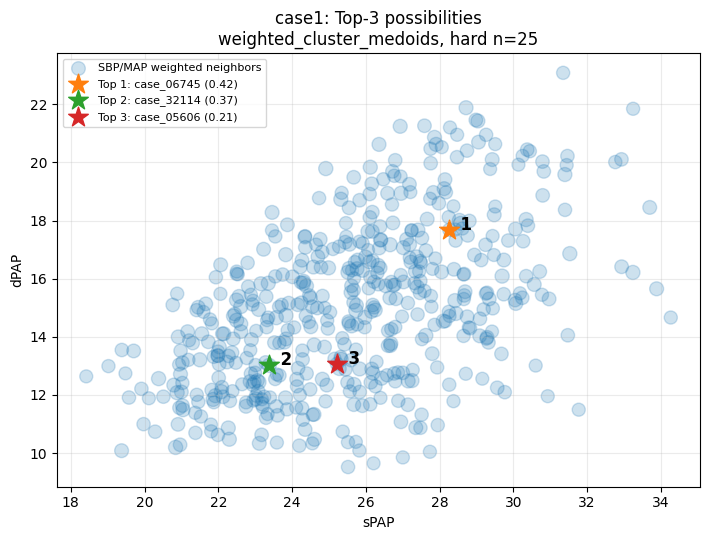

c:\Users\32526\anaconda3\envs\cvdl\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


case2
Targets: {'SBP': 136.0, 'MAP': 110.0}
Output summaries: ['sPAP', 'dPAP', 'mPAP', 'CO', 'SVR', 'PVR']
Hard matches within ±1.0: 4
Algorithm mode: weighted_cluster_medoids

Top 1
  case_id: case_02317
  possibility_score: 0.531
  input_distance: 0.0347
  SBP=135.909, MAP=109.410
  sPAP=22.277
  dPAP=13.369
  mPAP=17.413
  CO=3.343
  SVR=30.680
  PVR=1.700
  cluster_id: 1
  cluster_size: 255
  cluster_weight: 149.6935
  transform: standardized_output_space

Top 2
  case_id: case_12022
  possibility_score: 0.254
  input_distance: 0.1149
  SBP=137.089, MAP=111.659
  sPAP=22.551
  dPAP=13.716
  mPAP=17.826
  CO=3.783
  SVR=27.734
  PVR=1.836
  cluster_id: 2
  cluster_size: 129
  cluster_weight: 71.4786
  transform: standardized_output_space

Top 3
  case_id: case_27301
  possibility_score: 0.215
  input_distance: 0.0532
  SBP=136.744, MAP=109.453
  sPAP=27.820
  dPAP=18.103
  mPAP=22.782
  CO=3.433
  SVR=30.312
  PVR=3.239
  cluster_id: 0
  cluster_size: 116
  cluster_weight: 60.7155
 

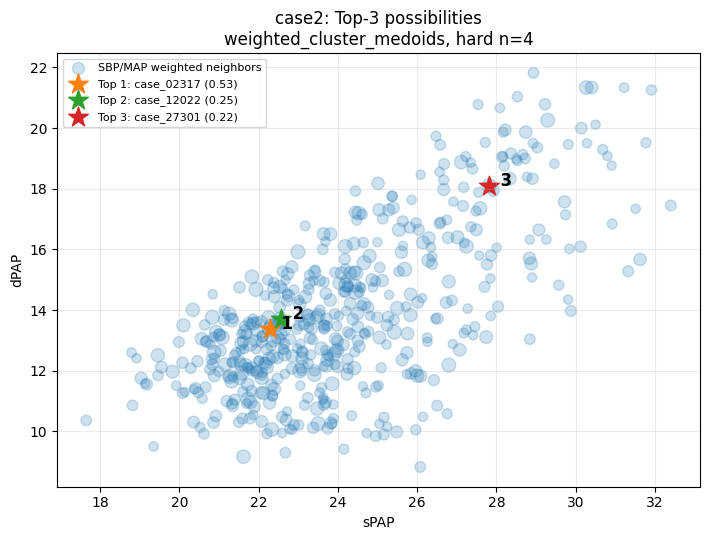

In [8]:
from pathlib import Path
import csv
import math
import subprocess
import sys
import importlib

def ensure_package(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ModuleNotFoundError:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            pip_name or import_name,
        ])
        return importlib.import_module(import_name)

np = ensure_package("numpy")
plt = ensure_package("matplotlib.pyplot", "matplotlib")
ensure_package("sklearn", "scikit-learn")

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


DATA_PATH = Path("dataset_40k_cases.csv")

INPUT_COLS = ["SBP", "MAP"]

TEST_CASES = [
    {"name": "case1", "targets": {"SBP": 100.0, "MAP": 90.0}},
    {"name": "case2", "targets": {"SBP": 136.0, "MAP": 110.0}},
]

# 自由改这里。
# 2-4 个会走 conditional KDE
# 4-10 个会走 weighted neighbors + clustering/medoids
# 10+ 个会走 PCA + clustering/medoids
#OUTPUT_COLS = ["sPAP", "dPAP", "mPAP", "CO"]
OUTPUT_COLS = ["sPAP", "dPAP", "mPAP", "CO", "SVR", "PVR"]

TOP_K = 3
HARD_TOLERANCE = 1.0
MIN_HARD_MATCHES = 10

K_NEIGHBORS = 500
INPUT_BANDWIDTH = 0.35
OUTPUT_BANDWIDTH = 1.2

N_CLUSTERS = 3
PCA_COMPONENTS = 6
RANDOM_STATE = 42


def to_float(x):
    try:
        return float(x)
    except Exception:
        return math.nan


def load_dataset(path):
    rows = []

    with path.open(newline="", encoding="utf-8-sig") as f:
        reader = csv.DictReader(f)
        fieldnames = reader.fieldnames

        required = ["case_id"] + INPUT_COLS + OUTPUT_COLS
        missing = [c for c in required if c not in fieldnames]
        if missing:
            raise ValueError(f"CSV 缺少这些列: {missing}")

        for row in reader:
            parsed = {"case_id": row["case_id"]}

            ok = True
            for col in INPUT_COLS + OUTPUT_COLS:
                parsed[col] = to_float(row[col])
                if math.isnan(parsed[col]):
                    ok = False

            if ok:
                rows.append(parsed)

    return rows


def hard_match_count(rows, targets):
    return sum(
        all(abs(r[col] - targets[col]) <= HARD_TOLERANCE for col in INPUT_COLS)
        for r in rows
    )


def get_weighted_neighbors(rows, targets, k=K_NEIGHBORS):
    input_matrix = np.array([[r[col] for col in INPUT_COLS] for r in rows], dtype=float)
    input_mean = input_matrix.mean(axis=0)
    input_std = input_matrix.std(axis=0)
    input_std[input_std == 0] = 1.0

    target_vec = np.array([targets[col] for col in INPUT_COLS], dtype=float)
    z_input = (input_matrix - input_mean) / input_std
    z_target = (target_vec - input_mean) / input_std

    distances = np.linalg.norm(z_input - z_target, axis=1)
    weights = np.exp(-0.5 * (distances / INPUT_BANDWIDTH) ** 2)

    idx = np.argsort(distances)[:k]

    neighbors = []
    for i in idx:
        item = dict(rows[i])
        item["input_distance"] = float(distances[i])
        item["input_weight"] = float(weights[i])
        neighbors.append(item)

    return neighbors


def normalize_scores(items, raw_key="raw_score", score_key="confidence_score"):
    total = sum(max(x[raw_key], 0.0) for x in items)
    for x in items:
        x[score_key] = max(x[raw_key], 0.0) / total if total > 0 else 0.0
    return items


def conditional_kde_real_samples(neighbors):
    """
    用于 2-4 个 output summary。

    对真实 case 评分：
    raw_score_i = input_weight_i * sum_j input_weight_j * K(output_i, output_j)

    score 越高，表示：
    1. 这个 case 的 SBP/MAP 更接近目标；
    2. 这个 case 的 output summary 位于局部高密度区域；
    3. 这个 case 本身是真实存在的。
    """
    Y = np.array([[r[col] for col in OUTPUT_COLS] for r in neighbors], dtype=float)
    weights = np.array([r["input_weight"] for r in neighbors], dtype=float)

    scaler = StandardScaler()
    Z = scaler.fit_transform(Y)

    scored = []

    for i, r in enumerate(neighbors):
        diff = Z - Z[i]
        dist2 = np.sum(diff ** 2, axis=1)

        output_density = np.sum(weights * np.exp(-0.5 * dist2 / (OUTPUT_BANDWIDTH ** 2)))
        raw_score = weights[i] * output_density

        item = dict(r)
        item["output_density"] = float(output_density)
        item["raw_score"] = float(raw_score)
        scored.append(item)

    normalize_scores(scored)
    scored.sort(key=lambda x: x["confidence_score"], reverse=True)
    return scored[:TOP_K], scored, "conditional_kde_real_samples"


def weighted_cluster_medoids(neighbors, use_pca=False):
    """
    用于 4+ 个 output summary。

    思想：
    1. 在 target SBP/MAP 附近取 weighted neighbors；
    2. 在 output summary 空间聚类；
    3. 每个 cluster 是一种 possible outcome mode；
    4. cluster confidence = cluster 内 input weights 总和 / 所有 weights 总和；
    5. 每个 cluster 输出 medoid，也就是真实存在、最代表该 cluster 的 case。
    """
    Y = np.array([[r[col] for col in OUTPUT_COLS] for r in neighbors], dtype=float)
    weights = np.array([r["input_weight"] for r in neighbors], dtype=float)

    scaler = StandardScaler()
    Z = scaler.fit_transform(Y)

    transform_note = "standardized_output_space"

    if use_pca:
        n_components = min(PCA_COMPONENTS, Z.shape[1], Z.shape[0] - 1)
        pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
        Z_model = pca.fit_transform(Z)
        transform_note = f"pca_{n_components}d_explained_var_{pca.explained_variance_ratio_.sum():.3f}"
    else:
        Z_model = Z

    n_clusters = min(N_CLUSTERS, len(neighbors))
    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init="auto")
    labels = kmeans.fit_predict(Z_model, sample_weight=weights)

    total_weight = weights.sum()
    possibilities = []

    for cluster_id in range(n_clusters):
        idx = np.where(labels == cluster_id)[0]
        if len(idx) == 0:
            continue

        cluster_weight = weights[idx].sum()
        center = kmeans.cluster_centers_[cluster_id]

        # weighted medoid: 真实 case，离 cluster center 最近，同时受 input proximity 奖励
        medoid_idx = min(
            idx,
            key=lambda i: np.linalg.norm(Z_model[i] - center) / max(weights[i], 1e-12)
        )

        medoid = dict(neighbors[int(medoid_idx)])
        medoid["cluster_id"] = int(cluster_id)
        medoid["cluster_size"] = int(len(idx))
        medoid["cluster_weight"] = float(cluster_weight)
        medoid["raw_score"] = float(cluster_weight / total_weight if total_weight > 0 else 0.0)
        medoid["transform"] = transform_note

        possibilities.append(medoid)

    normalize_scores(possibilities)
    possibilities.sort(key=lambda x: x["confidence_score"], reverse=True)

    mode = "pca_weighted_cluster_medoids" if use_pca else "weighted_cluster_medoids"
    return possibilities[:TOP_K], possibilities, mode


def predict_possibilities(rows, targets):
    n_outputs = len(OUTPUT_COLS)
    n_hard = hard_match_count(rows, targets)

    neighbors = get_weighted_neighbors(rows, targets)

    if 2 <= n_outputs <= 4:
        top, all_ranked, mode = conditional_kde_real_samples(neighbors)
    elif 4 < n_outputs <= 10:
        top, all_ranked, mode = weighted_cluster_medoids(neighbors, use_pca=False)
    else:
        top, all_ranked, mode = weighted_cluster_medoids(neighbors, use_pca=True)

    return {
        "targets": targets,
        "hard_match_count": n_hard,
        "mode": mode,
        "top": top,
        "all_ranked": all_ranked,
        "neighbors": neighbors,
    }


def print_result(case_name, result):
    print("=" * 90)
    print(case_name)
    print(f"Targets: {result['targets']}")
    print(f"Output summaries: {OUTPUT_COLS}")
    print(f"Hard matches within ±{HARD_TOLERANCE}: {result['hard_match_count']}")
    print(f"Algorithm mode: {result['mode']}")
    print()

    for rank, r in enumerate(result["top"], start=1):
        print(f"Top {rank}")
        print(f"  case_id: {r['case_id']}")
        print(f"  possibility_score: {r['confidence_score']:.3f}")
        print(f"  input_distance: {r['input_distance']:.4f}")
        print(f"  SBP={r['SBP']:.3f}, MAP={r['MAP']:.3f}")

        for col in OUTPUT_COLS:
            print(f"  {col}={r[col]:.3f}")

        if "cluster_id" in r:
            print(f"  cluster_id: {r['cluster_id']}")
            print(f"  cluster_size: {r['cluster_size']}")
            print(f"  cluster_weight: {r['cluster_weight']:.4f}")
            print(f"  transform: {r['transform']}")

        print()


def plot_result(case_name, result):
    if len(OUTPUT_COLS) < 2:
        return

    x_col, y_col = OUTPUT_COLS[0], OUTPUT_COLS[1]
    neighbors = result["neighbors"]
    top = result["top"]

    weights = np.array([r["input_weight"] for r in neighbors])
    max_w = weights.max() if len(weights) else 1.0
    sizes = 15 + 90 * weights / max_w

    plt.figure(figsize=(7.2, 5.5))

    plt.scatter(
        [r[x_col] for r in neighbors],
        [r[y_col] for r in neighbors],
        s=sizes,
        alpha=0.22,
        label="SBP/MAP weighted neighbors",
    )

    for i, r in enumerate(top, start=1):
        plt.scatter(
            [r[x_col]],
            [r[y_col]],
            s=220,
            marker="*",
            label=f"Top {i}: {r['case_id']} ({r['confidence_score']:.2f})",
        )
        plt.text(r[x_col], r[y_col], f"  {i}", fontsize=12, weight="bold")

    plt.title(
        f"{case_name}: Top-{TOP_K} possibilities\n"
        f"{result['mode']}, hard n={result['hard_match_count']}"
    )
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.grid(True, alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


rows = load_dataset(DATA_PATH)
print(f"Loaded rows: {len(rows)}")

for test_case in TEST_CASES:
    result = predict_possibilities(rows, test_case["targets"])
    print_result(test_case["name"], result)
    plot_result(test_case["name"], result)
